## test ensemble cma-es

larger run, 

In [2]:
# setup imports
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path().resolve().parents[2]  # pas aan als notebook dieper/dichter zit
sys.path.append(str(PROJECT_ROOT))

In [3]:
from ewatercycle.observation.grdc import get_grdc_data

from src.forcing import load_lumped_forcing
from src.models import *
from src.paths import *

/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


In [4]:
ERA5_forcing_loaded = load_lumped_forcing("Kerki_GRDC", "ERA5", "1959-1963")
theta_test = np.mean(generate_HBV_parameters(100), axis=0)

grdc_station = get_grdc_data(
    2617110, "1959-01-02T00:00Z", "1963-12-31T00:00Z", data_home=GRDC / "Daily"
)

q_obs = grdc_station["streamflow"]
years = q_obs["time"].dt.year.values
shape_name = "Kerki_GRDC"

In [4]:
# sigma0 = 0.1  # step size in normalized space
# # perturb initial guess slightly (±10% of sigma0)
# def randomize_x0(x0, sigma0, scale=1):
#     noise = np.random.uniform(-scale * sigma0, scale * sigma0, size=x0.shape)
#     x0_rand = x0 + noise
#     # ensure bounds [0,1] for normalized parameters
#     return np.clip(x0_rand, 0, 1)

# # Example usage
# x0_norm_base = scale(0.5 * (p_min + p_max))
# x0_norm_random = randomize_x0(x0_norm_base, sigma0)

# print(x0_norm_random)

In [ ]:
# CMA-ES test setup
x0_norm = scale(0.5 * (p_min + p_max))  # start in the middle
sigma0 = 0.1  # step size in normalized space

# Define 20 unique seeds
seeds = [
    180988,
    214025,
    987654,
    123456,
    654321,
    111222,
    333444,
    555666,
    777888,
    999000,
    112233,
    445566,
    778899,
    101010,
    202020,
    303030,
    404040,
    505050,
    606060,
    707070,
]

# Run CMA-ES ensemble
results = run_cma_ensemble(
    objective_safe,
    x0_norm,
    sigma0,
    args=(ERA5_forcing_loaded, q_obs.values, shape_name),
    p_min=p_min,
    p_max=p_max,
    seeds=seeds,
    popsize=18,
    maxfevals=360,
)

(7_w,15)-aCMA-ES (mu_w=4.5,w_1=34%) in dimension 9 (seed=180988, Fri Jan 23 13:33:48 2026)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     15 3.303692023026911e-01 1.0e+00 1.12e-01  1e-01  1e-01 1:28.4
    2     30 2.703759985714722e-01 1.3e+00 1.33e-01  1e-01  1e-01 2:56.8
    3     45 2.295676332624682e-01 1.5e+00 1.55e-01  1e-01  2e-01 4:24.2
    4     60 2.270429359877191e-01 1.6e+00 1.60e-01  1e-01  2e-01 5:51.7
    5     75 2.680337101316332e-01 1.6e+00 1.51e-01  1e-01  2e-01 7:21.5
    6     90 2.327188437936094e-01 1.6e+00 1.55e-01  1e-01  2e-01 8:49.1
    7    105 2.226284085118174e-01 1.5e+00 1.68e-01  1e-01  2e-01 10:19.0
    8    120 1.963597272066234e-01 1.7e+00 2.04e-01  2e-01  2e-01 11:48.2
    9    135 2.089113416567287e-01 1.9e+00 2.15e-01  2e-01  2e-01 13:15.9
   10    150 1.880742638803715e-01 2.1e+00 2.11e-01  2e-01  2e-01 14:43.6
   11    165 2.202097270588254e-01 2.2e+00 2.10e-01  2e-01  2e-01 16:11.5
   12    180 2.11919338945267

In [ ]:
import os
import pickle

import pandas as pd

# Folder for saving
folder = "results"
os.makedirs(folder, exist_ok=True)

# Save each run as a .pkl containing both res and history
for result in results:
    seed = result["seed"]
    data_to_save = {"seed": seed, "res": result["res"], "history": result["history"]}

    path = os.path.join(folder, f"cma_run_seed_{seed}.pkl")
    with open(path, "wb") as f:
        pickle.dump(data_to_save, f)

    print(f"Saved CMA-ES run for seed {seed} to {path}")

# Optional: save all runs in a single .pkl
all_data_path = os.path.join(folder, "cma_all_seeds.pkl")
with open(all_data_path, "wb") as f:
    pickle.dump(results, f)
print(f"All CMA-ES runs saved to {all_data_path}")

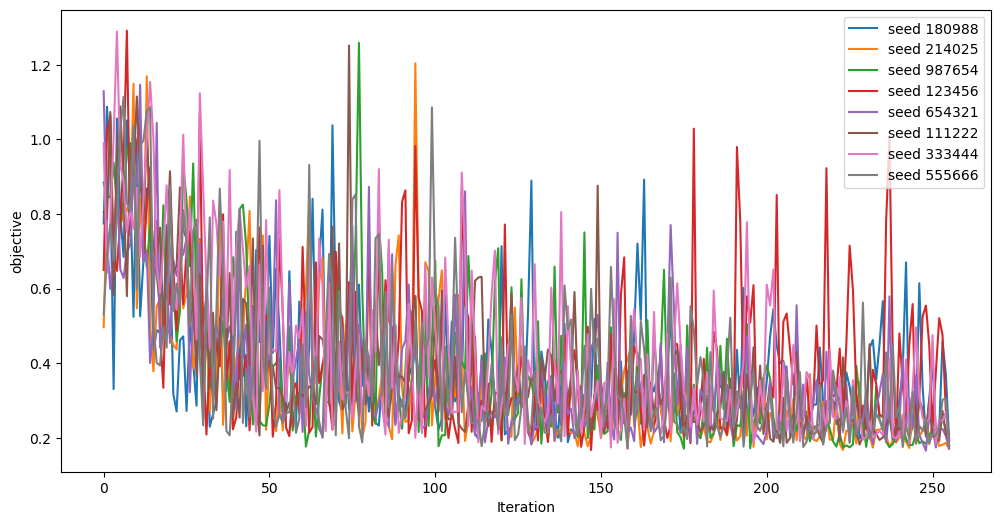

In [ ]:
plt.figure(figsize=(12, 6))
for r in results:
    plt.plot(r["history"]["objective"], alpha=0.7)  # , label=f"seed {r['seed']}")
plt.xlabel("Iteration")
plt.ylabel("objective")
plt.legend()
plt.show()

In [7]:
results[1]["history"]

,theta_norm,theta_phys,objective,nse,kge,vol_err
0,"[0.38114714434911406, 0.7504795237371815, 0.40...","[9.528678608727851, 0.8003836189897453, 350.13...",0.496331,0.368342,0.480885,0.377748
1,"[0.4890854515969778, 0.4645414103555474, 0.597...","[12.227136289924445, 0.571633128284438, 494.37...",0.819651,-0.116280,0.183976,0.599900
2,"[0.4080964397700429, 0.4190257081245963, 0.450...","[10.202410994251073, 0.535220566499677, 382.60...",1.062598,-0.558425,-0.016011,0.725668
3,"[0.46298858368873863, 0.57958276741169, 0.5547...","[11.574714592218466, 0.6636662139293521, 461.6...",0.634318,0.182687,0.346040,0.482341
4,"[0.5609679644871467, 0.6523225414067393, 0.421...","[14.024199112178668, 0.7218580331253914, 360.4...",0.663226,0.132559,0.314017,0.492997
...,...,...,...,...,...,...
251,"[0.4440430151173334, 0.6400049946322539, 0.348...","[11.101075377933336, 0.7120039957058031, 304.6...",0.211204,0.625010,0.797750,0.095080
252,"[0.31384847513579595, 0.7281011193907667, 0.27...","[7.846211878394898, 0.7824808955126135, 251.87...",0.177850,0.609956,0.808879,0.008750
253,"[0.4110653534445325, 0.7603971324013067, 0.239...","[10.276633836113312, 0.8083177059210453, 221.6...",0.181325,0.614164,0.810147,0.021546
254,"[0.2656194879632207, 0.7844984442257426, 0.322...","[6.640487199080518, 0.8275987553805941, 284.91...",0.186102,0.609505,0.804345,0.025642


In [8]:
# assuming results[0]['history'] is your history dictionary
history_dict = results[0]["history"]

# convert to DataFrame
history_df = pd.DataFrame(history_dict)

# optionally, add a column for evaluation index if not already there
history_df["f_eval"] = history_df.index + 1

# check
print(history_df.head())

                                          theta_norm  \
0  [0.6055435978528811, 0.4631331128245731, 0.328...   
1  [0.6212918177151726, 0.47004691136879295, 0.56...   
2  [0.6082412132934497, 0.6940199096272062, 0.746...   
3  [0.48985361080226697, 0.6784374072226353, 0.49...   
4  [0.4823774715930444, 0.48493912161474273, 0.58...   

                                          theta_phys  objective       nse  \
0  [15.138589946322028, 0.5705064902596585, 289.3...   0.774475 -0.042613   
1  [15.532295442879315, 0.5760375290950344, 471.9...   1.087380 -0.604066   
2  [15.206030332336242, 0.7552159277017649, 607.4...   0.917753 -0.299770   
3  [12.246340270056674, 0.7427499257781083, 413.9...   0.330369  0.541373   
4  [12.05943678982611, 0.5879512972917942, 484.46...   1.056145 -0.548694   

        kge   vol_err  f_eval  
0  0.242210  0.585885       1  
1 -0.023122  0.748059       2  
2  0.087704  0.635332       3  
3  0.688069  0.248004       4  
4 -0.012991  0.719100       5  


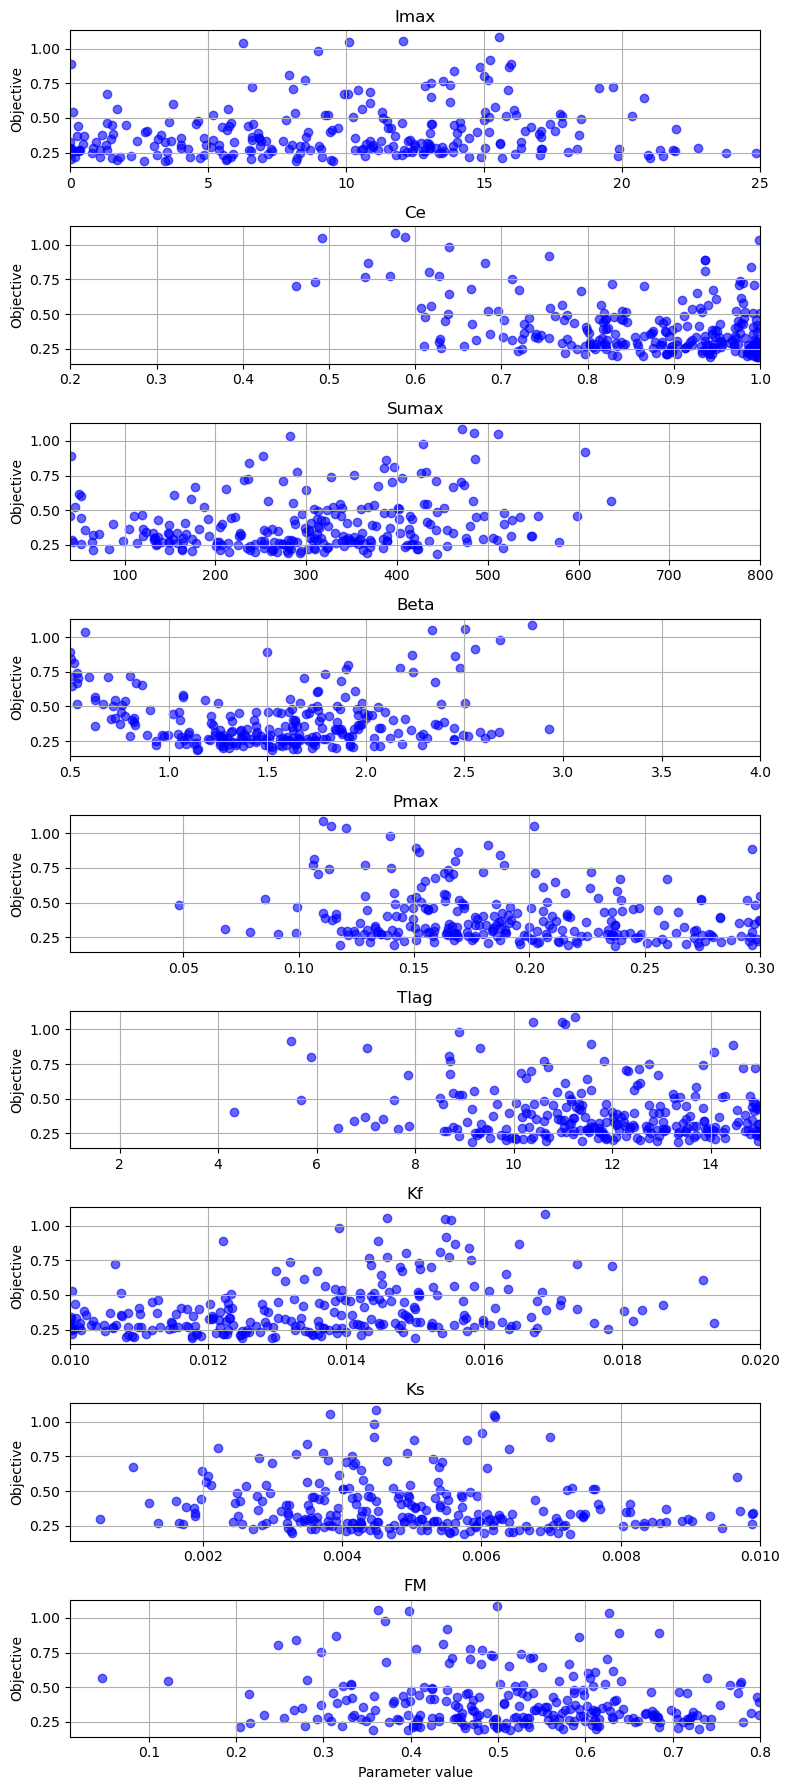

In [9]:
import matplotlib.pyplot as plt
import numpy as np

n_params = len(p_min)  # 9
theta_array = np.stack(history_df["theta_phys"].values)  # shape: (n_eval, n_params)

fig, axes = plt.subplots(n_params, 1, figsize=(8, 2 * n_params), sharex=False)

for i in range(n_params):
    ax = axes[i]
    ax.scatter(theta_array[:, i], history_df["objective"], c="blue", alpha=0.6)
    ax.set_ylabel("Objective")
    ax.set_title(parameter_names[i])  # optional
    ax.set_xlim(p_min[i], p_max[i])
    ax.grid(True)

axes[-1].set_xlabel("Parameter value")
plt.tight_layout()
plt.show()

In [10]:
for k, v in results[0].items():
    print(k, type(v))

seed <class 'int'>
res <class 'tuple'>
history <class 'pandas.core.frame.DataFrame'>


In [11]:
params1 = results[0]["res"][5]
params1_unscaled = unscale(params1)

print("Physical HBV parameters:")
for i, th in enumerate(params1_unscaled):
    print(f"Param {i}: {th:.4f}")

Physical HBV parameters:
Param 0: 3.4386
Param 1: 0.9989
Param 2: 279.5474
Param 3: 1.6320
Param 4: 0.2168
Param 5: 11.3902
Param 6: 0.0125
Param 7: 0.0045
Param 8: 0.5140


In [12]:
for run_idx, run in enumerate(results):
    print(f"\n--- Seed {run['seed']} (Run {run_idx}) ---")

    # pick the best parameter set by lowest objective value
    history = run["history"]
    best_idx = np.argmin(history["objective"])

    best_theta_norm = history["theta_norm"][best_idx]
    best_theta_phys = history["theta_phys"][best_idx]

    print(f"Best evaluation #{best_idx+1}, objective = {history['objective'][best_idx]:.4f}")
    print("Physical HBV parameters:")
    for i, th in enumerate(best_theta_phys):
        print(f"  Param {i}: {th:.4f}")


--- Seed 180988 (Run 0) ---
Best evaluation #141, objective = 0.1881
Physical HBV parameters:
  Param 0: 8.1726
  Param 1: 0.9425
  Param 2: 444.2631
  Param 3: 1.1410
  Param 4: 0.2372
  Param 5: 13.3338
  Param 6: 0.0129
  Param 7: 0.0073
  Param 8: 0.3968

--- Seed 214025 (Run 1) ---
Best evaluation #224, objective = 0.1672
Physical HBV parameters:
  Param 0: 10.7454
  Param 1: 0.8414
  Param 2: 289.0755
  Param 3: 1.1374
  Param 4: 0.1811
  Param 5: 7.1839
  Param 6: 0.0109
  Param 7: 0.0093
  Param 8: 0.4720

--- Seed 987654 (Run 2) ---
Best evaluation #176, objective = 0.1706
Physical HBV parameters:
  Param 0: 4.9154
  Param 1: 0.7684
  Param 2: 372.4549
  Param 3: 0.9508
  Param 4: 0.1408
  Param 5: 8.1056
  Param 6: 0.0127
  Param 7: 0.0053
  Param 8: 0.3301

--- Seed 123456 (Run 3) ---
Best evaluation #148, objective = 0.1671
Physical HBV parameters:
  Param 0: 3.3609
  Param 1: 0.9128
  Param 2: 327.2043
  Param 3: 1.1472
  Param 4: 0.0227
  Param 5: 3.2240
  Param 6: 0.010

In [13]:
import numpy as np
import pandas as pd

parameter_names = [
    "Imax",  # 0
    "Ce",  # 1
    "Sumax",  # 2
    "Beta",  # 3
    "Pmax",  # 4
    "Tlag",  # 5
    "Kf",  # 6
    "Ks",  # 7
    "FM",  # 8
]

best_params_list = []

for run_idx, run in enumerate(results):
    seed = run["seed"]
    history = run["history"]

    # find the best evaluation by objective value
    best_idx = np.argmin(history["objective"])

    best_theta_phys = history["theta_phys"][best_idx]
    best_obj = history["objective"][best_idx]
    best_nse = history["nse"][best_idx]
    best_kge = history["kge"][best_idx]
    best_vol_err = history["vol_err"][best_idx]

    row = {
        "seed": seed,
        "best_eval": best_idx + 1,
        "objective": best_obj,
        "nse": best_nse,
        "kge": best_kge,
        "vol_err": best_vol_err,
    }

    # add each parameter with its proper name
    for i, th in enumerate(best_theta_phys):
        row[parameter_names[i]] = th

    best_params_list.append(row)

# create DataFrame
best_params_df = pd.DataFrame(best_params_list)
best_params_df

,seed,best_eval,objective,nse,kge,vol_err,Imax,Ce,Sumax,Beta,Pmax,Tlag,Kf,Ks,FM
0,180988,141,0.188074,0.592911,0.795925,0.011813,8.172609,0.942513,444.263054,1.141037,0.237225,13.333830,0.012920,0.007267,0.396769
1,214025,224,0.167192,0.629595,0.817277,0.003134,10.745414,0.841426,289.075545,1.137441,0.181071,7.183904,0.010912,0.009273,0.472024
2,987654,176,0.170641,0.618811,0.812769,0.000288,4.915427,0.768375,372.454916,0.950800,0.140757,8.105642,0.012733,0.005266,0.330150
3,123456,148,0.167064,0.631414,0.815352,0.002734,3.360939,0.912804,327.204288,1.147237,0.022685,3.223987,0.010501,0.005362,0.448359
4,654321,249,0.165191,0.634309,0.816494,0.001079,7.917886,0.661408,592.624344,0.741859,0.079752,2.610360,0.012018,0.006836,0.368487
5,111222,229,0.181742,0.593405,0.800992,0.000153,17.545024,0.841614,127.529386,1.243744,0.135927,10.719455,0.011152,0.006529,0.331570
6,333444,159,0.170678,0.625665,0.813499,0.006069,4.895986,0.908027,375.429100,1.194780,0.268284,5.267834,0.013423,0.009306,0.334228
7,555666,159,0.172913,0.624280,0.815438,0.012071,4.474632,0.880568,262.154745,1.307838,0.148214,6.874354,0.011669,0.005102,0.426282


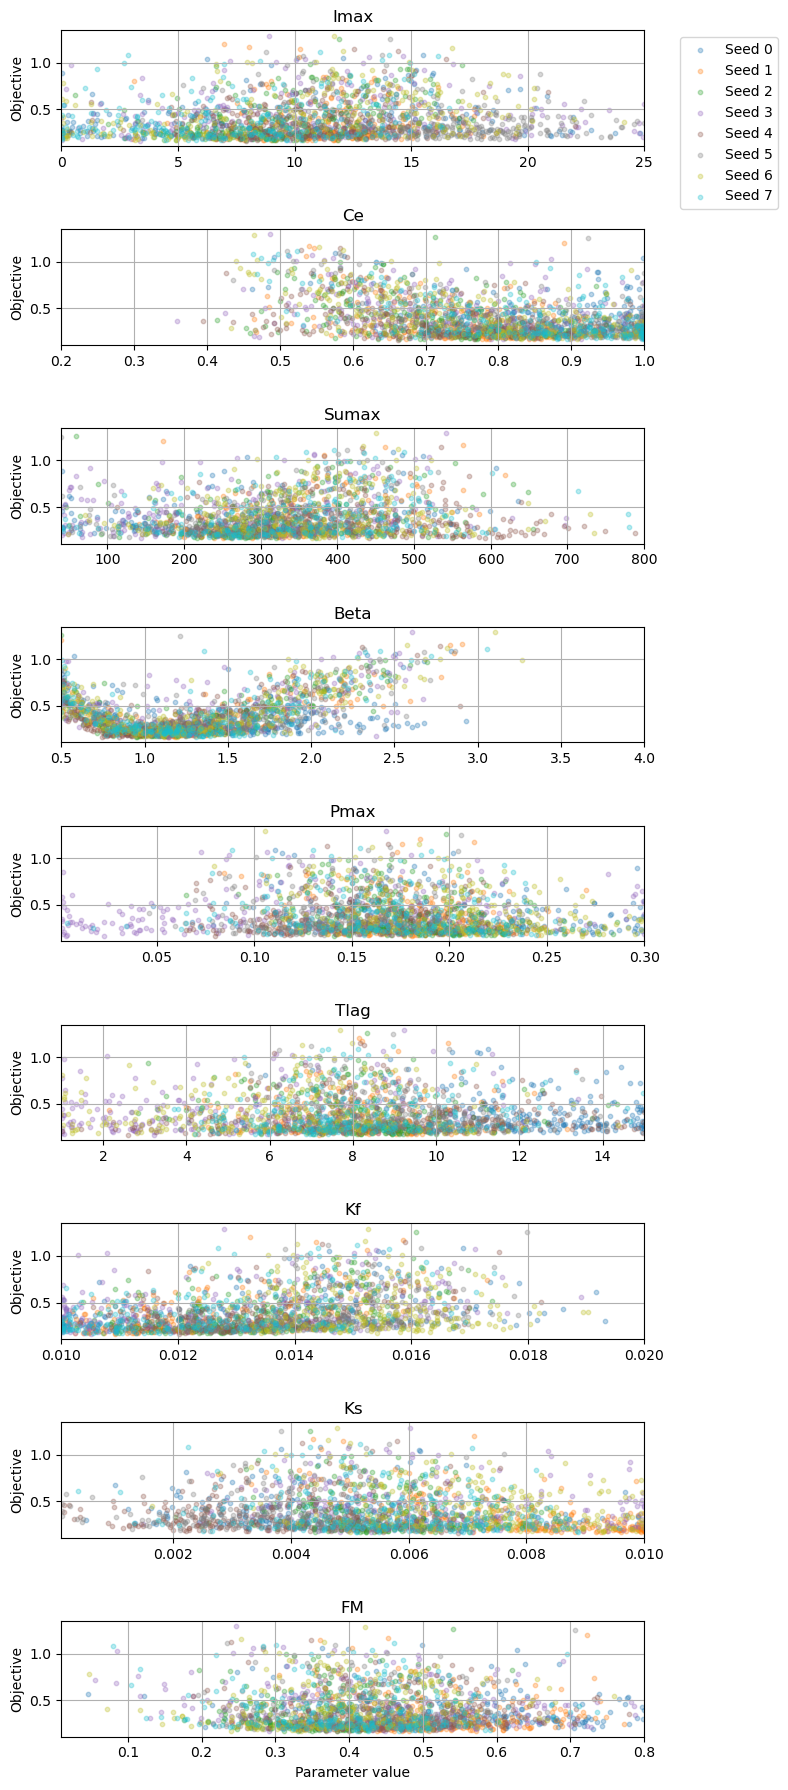

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Suppose you have multiple seeds in `results`:
dfs = []
for seed_idx, res_seed in enumerate(results):
    hist = res_seed["history"]
    df = pd.DataFrame(hist)
    df["seed"] = seed_idx  # add a seed column
    dfs.append(df)

history_df = pd.concat(dfs, ignore_index=True)


n_params = len(p_min)  # 9
seeds = history_df["seed"].unique()  # get all unique seeds
colors = plt.cm.tab10(np.linspace(0, 1, len(seeds)))  # assign colors

fig, axes = plt.subplots(n_params, 1, figsize=(8, 2 * n_params), sharex=False)

for i in range(n_params):
    ax = axes[i]

    for seed, color in zip(seeds, colors):
        # select rows for this seed
        theta_array = np.stack(history_df.loc[history_df["seed"] == seed, "theta_phys"].values)
        obj_array = history_df.loc[history_df["seed"] == seed, "objective"].values

        ax.scatter(theta_array[:, i], obj_array, label=f"Seed {seed}", color=color, alpha=0.3, s=10)

    ax.set_ylabel("Objective")
    ax.set_title(parameter_names[i])
    ax.set_xlim(p_min[i], p_max[i])
    ax.grid(True)

axes[-1].set_xlabel("Parameter value")
axes[0].legend(bbox_to_anchor=(1.05, 1), loc="upper left")  # legend outside
plt.tight_layout()
plt.show()

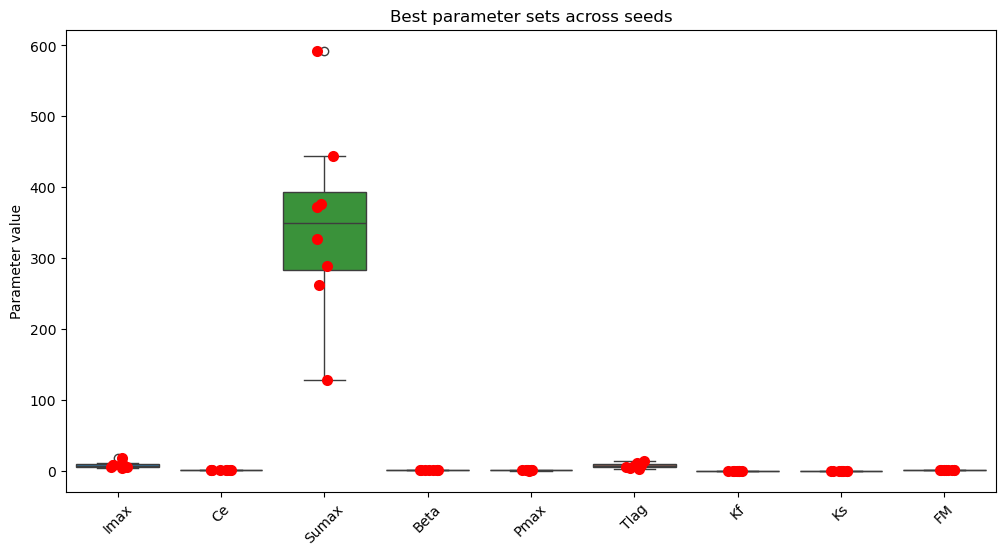

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only the parameters
param_cols = ["Imax", "Ce", "Sumax", "Beta", "Pmax", "Tlag", "Kf", "Ks", "FM"]

plt.figure(figsize=(12, 6))
sns.boxplot(data=best_params_df[param_cols])
sns.stripplot(data=best_params_df[param_cols], color="red", jitter=True, size=8)
plt.xticks(rotation=45)
plt.ylabel("Parameter value")
plt.title("Best parameter sets across seeds")
plt.show()

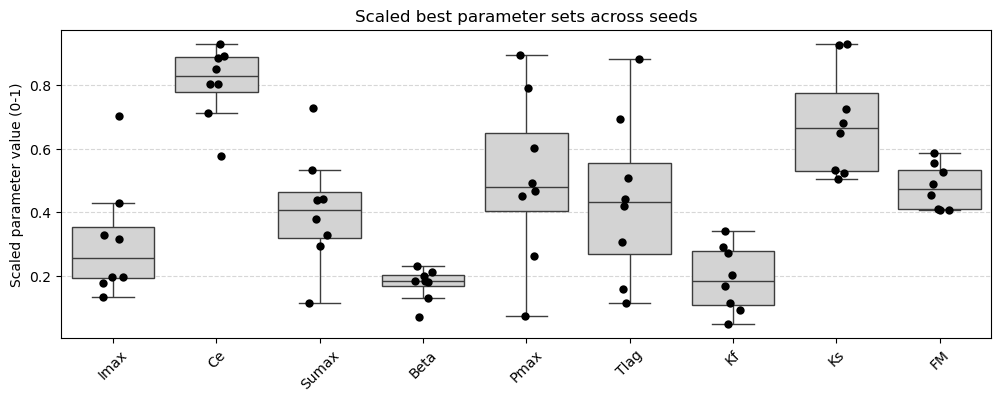

In [32]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Parameter columns
param_cols = ["Imax", "Ce", "Sumax", "Beta", "Pmax", "Tlag", "Kf", "Ks", "FM"]

# Scale the best parameters
scaled_params_df = pd.DataFrame(scale(best_params_df[param_cols].to_numpy()), columns=param_cols)


plt.figure(figsize=(12, 4))
# sns.boxplot(data=scaled_params_df, color = 'lightgray')
# sns.stripplot(data=scaled_params_df, color='black', jitter=False, size=8)
sns.boxplot(
    data=scaled_params_df, color="lightgray", fliersize=0
)  # light gray boxes, hide default outliers
sns.stripplot(data=scaled_params_df, color="black", jitter=True, size=6, marker="o")  # black dots

plt.xticks(rotation=45)
plt.ylabel("Scaled parameter value (0-1)")
plt.title("Scaled best parameter sets across seeds")
# add horizontal grid lines
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

/tmp/ipykernel_261904/656558648.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



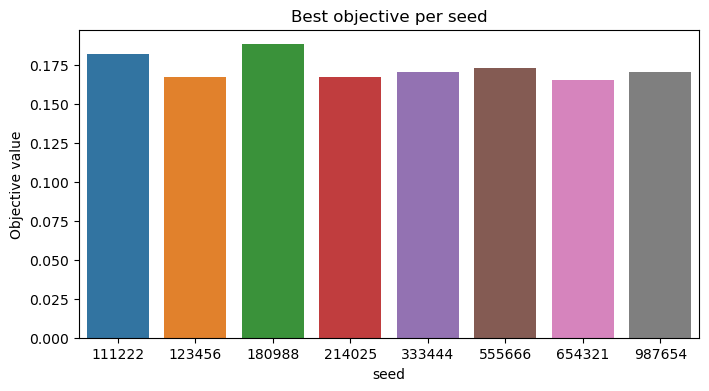

In [17]:
plt.figure(figsize=(8, 4))
sns.barplot(x="seed", y="objective", data=best_params_df, palette="tab10")
plt.ylabel("Objective value")
plt.title("Best objective per seed")
plt.show()

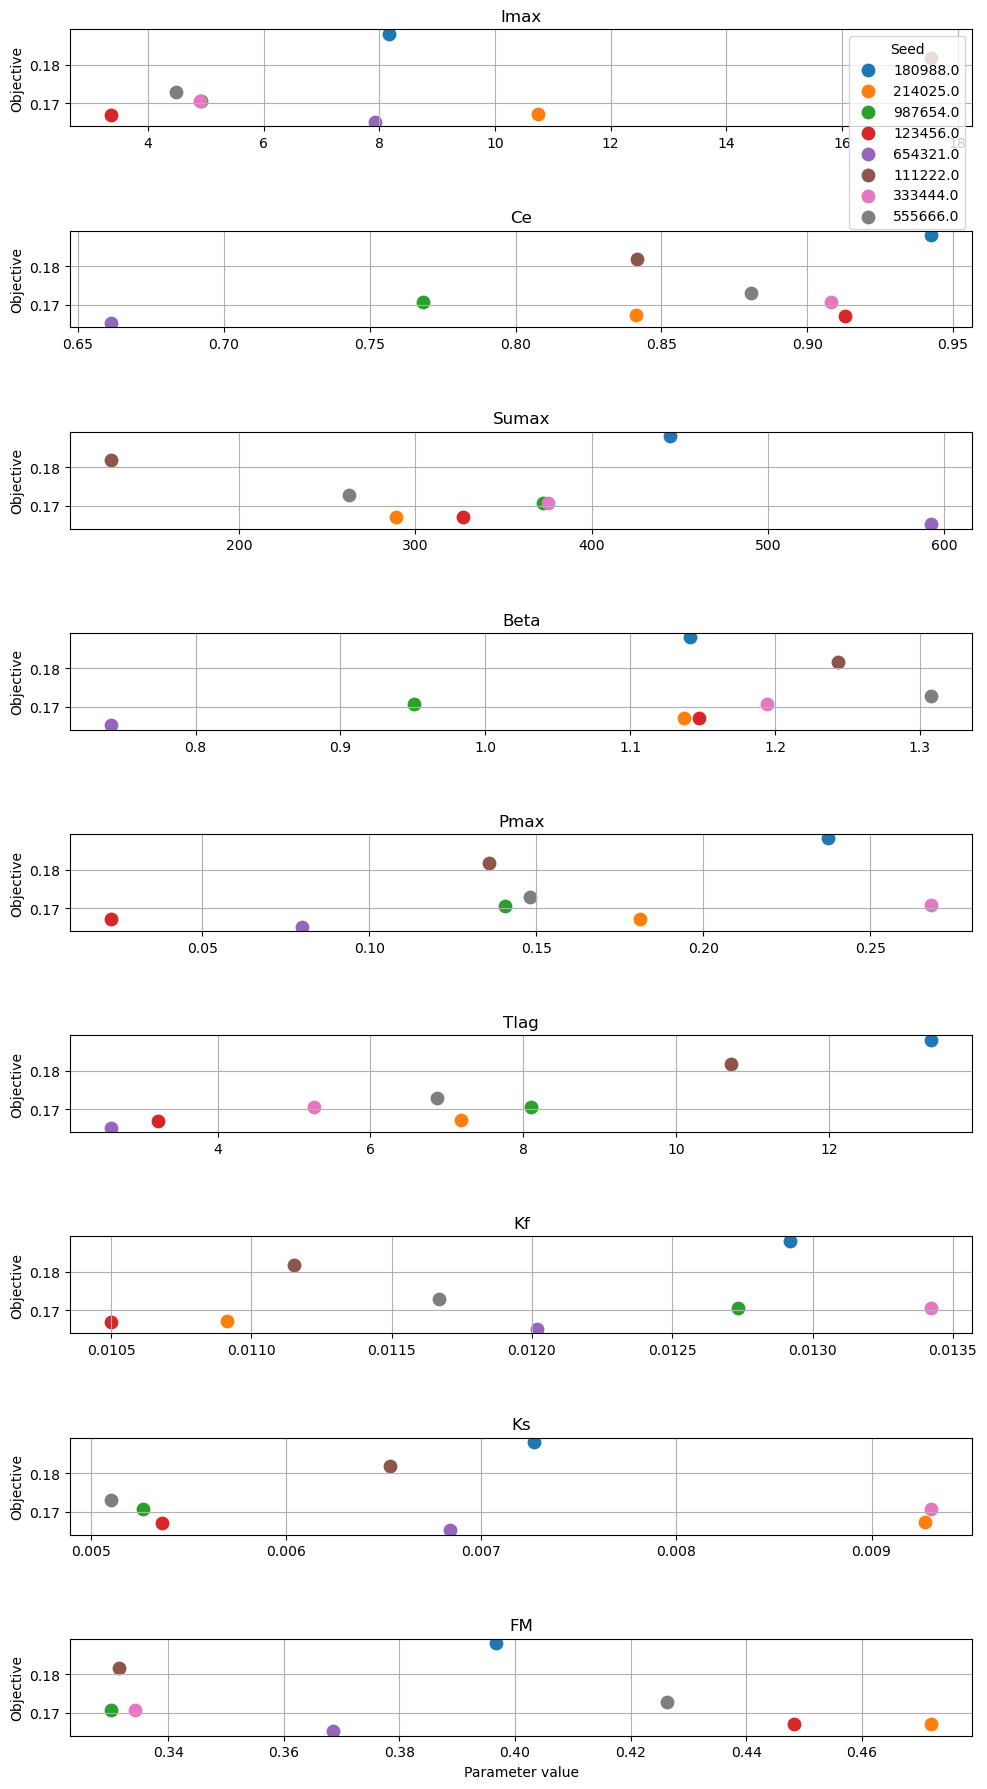

In [18]:
n_params = len(param_cols)
fig, axes = plt.subplots(n_params, 1, figsize=(10, 2 * n_params), sharex=False)

colors = plt.cm.tab10(range(len(best_params_df)))

for i, param in enumerate(param_cols):
    ax = axes[i]
    for j, row in best_params_df.iterrows():
        ax.scatter(
            row[param], row["objective"], color=colors[j], s=80, label=row["seed"] if i == 0 else ""
        )
    ax.set_ylabel("Objective")
    ax.set_title(param)
    ax.grid(True)

axes[-1].set_xlabel("Parameter value")
axes[0].legend(title="Seed")
plt.tight_layout()
plt.show()

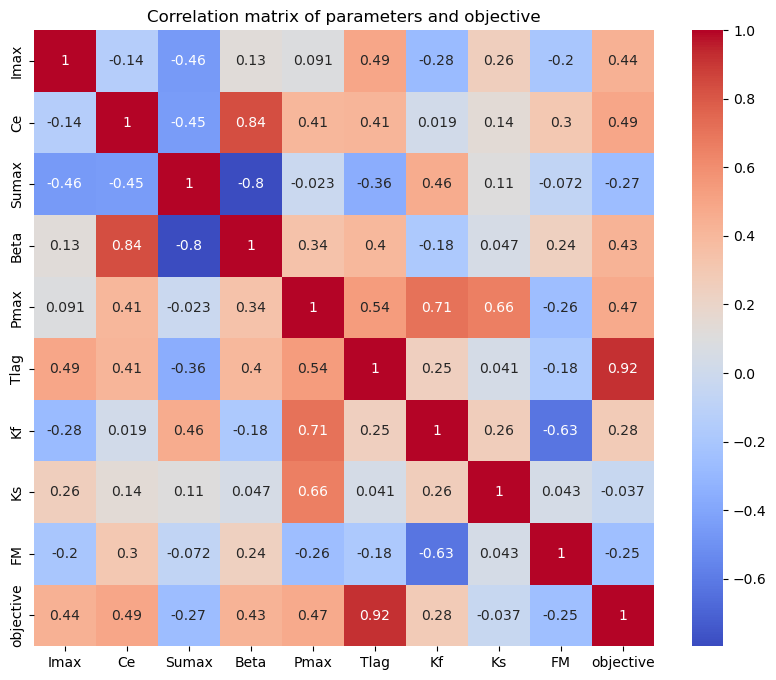